### Prošli čas smo uveli IF, i FOR i WHILE petlje.

Hajde da se toga brzinski podsjetimo.

In [1]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
mass = np.array([0.01, 0.5, 4, 0.0004, 3e-3, 5]) #3e-3 znači 3*10**(-3) [M_Sun]

# Koliko ima zvijezda u mom nizu mass? 

zvezde = np.where(mass>0.08) #uslov da je zvijezda je da ima masu veću od 0.08M_Sun

print(zvezde)
print(len(zvezde[0])) #vidim koliko ima zvijezda u mom nizu

if mass[0] > 0.001:
    print('Veće je od 0.001')
elif mass[0] < 0.02:
    print('Manja od 0.02')

(array([1, 2, 5]),)
3
Veće je od 0.001


### Funkcije i definisanje funkcija

Hajde sada da vidimo kako definišemo funkcije i zašto nam je to važno. 

Pominjemo i scipy - nova biblioteka koja znači science-python i uvodimo modul constants. 

In [3]:
const.c # brzina svetlosti

299792458.0

In [4]:
def luminoznost(R, Teff): #def + ime funkcije + u zagradi promenljive
    # od kojim data funkcija zavisi
    povrsina_zvezde = 4 * np.pi * R**2 
    izracena_energija = const.sigma * Teff**4 # Štefan-Bolcmanov zakon
    L = povrsina_zvezde * izracena_energija # snaga koju zrači zvezda
    return L # funkcija mi vraća ovu vrednost

# luminoznost Sunca
T_eff_s = 5780  # [K]
R_s = 696340 * 1e3 #[m]
L_s = luminoznost(R_s, T_eff_s)
print(f'Luminoznost sunca: {L_s:.3e}W') # [W]

Luminoznost sunca: 3.856e+26W


Text(0, 0.5, 'Luminoznost')

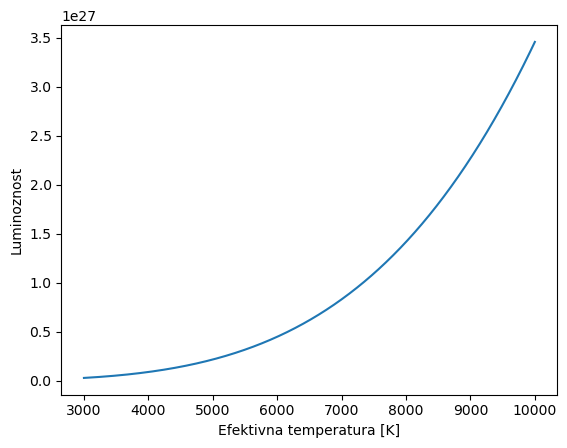

In [5]:
T_eff = np.linspace(3000, 10000, 1000)
L = luminoznost(R_s, T_eff)

plt.figure()
plt.plot(T_eff, L)
plt.xlabel('Efektivna temperatura [K]')
plt.ylabel('Luminoznost')

### 1. Napisati funkciju koja računa intenzitet zračenja crnog tela (Plankova funckija) za datu temperaturu i talasnu duzinu (ili niz talasnih duzina). Nacrtati spektar zračenja crnog tela koristeći efektivnu temperaturu Sunca za opseg talasnih dužina od $100 nm$ do $10 \mu m $. Označi maksimum fluksa crvenom tačkom na grafiku.

Plankova funkcija data je izrazom:

$B_\lambda = \frac{2hc^2}{\lambda^5}\frac{1}{e^\frac{hc}{\lambda kT}-1} $

gde je $h$ Plankova konstanta, $c$ brzina svetlosti, $\lambda$ talasna dužina, $k$ Bolcmanova konstanta, a $T$ temperatura na kojoj dato apsolutno crno telo zrači. Dakle, ova funkcija opisuje koliki je intenzitet zračena datog tela na određenoj talasnoj dužini, u zavisnosti od temperature.

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_30293/3570726055.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda[nm]$') #koristim $$, \ i LateX žargon da dobijem grčka slova
/tmp/ipykernel_30293/3570726055.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$B_\lambda$')


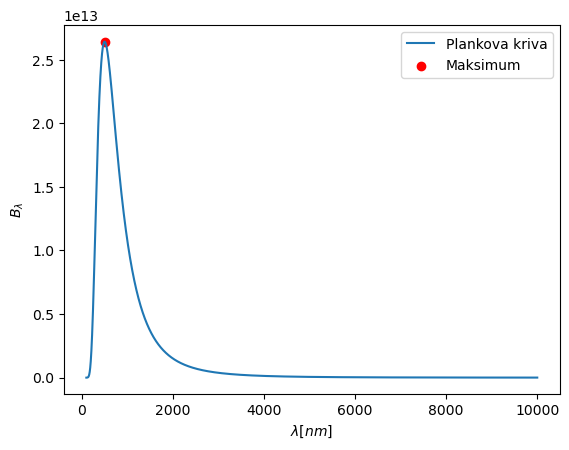

In [6]:
def plankova_funkcija(lam, T): #funkcija mi zavisi od talasne dužine i temperature
    #ali u Python-u ne mogu da koristim promenljivu sa nazivom lambda
    #zato što je lambda argument koji Python već koristi! 
    #isto tako, ne bih mogla da koristim promenljive pod nazivom ''def'' ili ''while'' 
    #ili bilo koja druga reč koja je već iskorištena u Pythonu  
    B = 2*const.h*const.c**2 / (lam**5 * (np.exp(const.h*const.c/(lam*const.k*T)) - 1))
    return B

T_eff_s = 5780  # [K]
talasne_duzine = np.linspace(100e-9, 10e-6, 100000)  #[m]
spektar = plankova_funkcija(talasne_duzine, T_eff_s)

plt.figure()
plt.plot(talasne_duzine*1e9, spektar, label='Plankova kriva')  # x-osa u [nm]
plt.scatter(talasne_duzine[np.argmax(spektar)]*1e9, max(spektar), c='r', label='Maksimum')
#talasne_duzine[np.argwhere(spektar==max(spektar))] - može i ovako
plt.xlabel('$\lambda[nm]$') #koristim $$, \ i LateX žargon da dobijem grčka slova
plt.ylabel('$B_\lambda$')
plt.legend() #obzirom da sam napisala label za scatter i plot, ova komanda ih printa
#ako imam labels, a ne dodam plt.legend(), oni neće biti prikazani

### 2. Potom, iz Plankove funckije naći na kojoj talasnoj dužini je maksimum za neki opseg temperatura (npr. između 3000 i 10000K), i prikazati zavisnost talasne dužine na kojoj se nalazi maksimum zračenja od temperature. 

Text(0, 0.5, 'Talasna dužina maksimuma [m]')

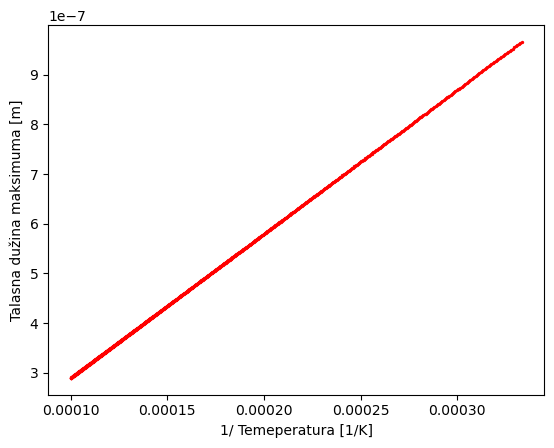

In [7]:
T = np.linspace(3000, 10000, 1000) #[K]

lambda_max = np.zeros(len(T)) #niz nula koji ima istu dužinu kao T

for i in range(len(T)): 
    spektar = plankova_funkcija(talasne_duzine, T[i])
    lambda_max[i] = talasne_duzine[np.argmax(spektar)]

plt.figure()
plt.scatter(1/T, lambda_max, s=2, c='r')
plt.xlabel('1/ Temeperatura [1/K]')
plt.ylabel('Talasna dužina maksimuma [m]')

Ono što smo dobili, zapravo jeste Vinov zakon pomjeranja, koji nam govori zavisnost talasne dužine na kojoj imamo maksimum zračenja od temperature: 

$\lambda_{max} = \frac{b}{T}$, 

gde nam je $b$ konstanta. Kako da odredimo konstantu $b$? Ono što mogu da odradim, jeste da fitujem datu zavisnost!

Ja vidim da je zavisnost talasne dužine od temperature linearna. Mogu da probam da fitujem linearno. Lak način da to uradim je fitovanje polinomom iz numpy biblioteke.

In [8]:
b, a = np.polyfit(1/T, lambda_max, 1) #polyfit pomaže da fitujem date podatke polinomom
#potrebno je da zadam x i y-osu i da kažem koji stepen polinoma hoću 

print(b)

0.0028977618962170238


Na ovaj način dobijam $b$ koje mi je zapravo Vinova konstanta. 

Nekad nam polinom ne može pomoći, ali mi znamo kojom drugom funkcijom hoćemo da fitujemo neke podatke (najčešće to znamo iz nekih fizičkih zakona) i potrebno je da definišemo tu funkciju, pa da onda fitujemo. Hajde da probamo da dobijemo b i na ovaj način.

In [9]:
from scipy.optimize import curve_fit

def linearna_funkcija(x, a, b):
    return b*x + a

popt, pcov = curve_fit(linearna_funkcija, 1/T, lambda_max)
#najčešće pišemo popt i pcov, zato što p znači optimal parameters, 
#a pcov znači parameter covariance

b = popt[1] # ovo je moje b
print(b) # opet sam dobila Vinovu konstantu! 

0.002897761886279207


### 3. Učitati podatke iz fajla linija.txt, gde imamo dve kolone: prva kolona je talasna dužina u [A] ($1A = 10^{-10}m$), a druga kolona je odnos intenziteta svetlosti u liniji i u kontinuumu [bezdimenziono]. Zatim, prikazati podatke. Pretpostavimo da linija može da se opšiše Gausovim profilom. Definisati funkciju koja je Gausov profil, a onda njome fitovati zadate podatke. 

Parametri fita
A = -0.20749505510425093
mu = 5396.052197161705
sigma = 0.09496657681092424
C = 0.9960757088133928


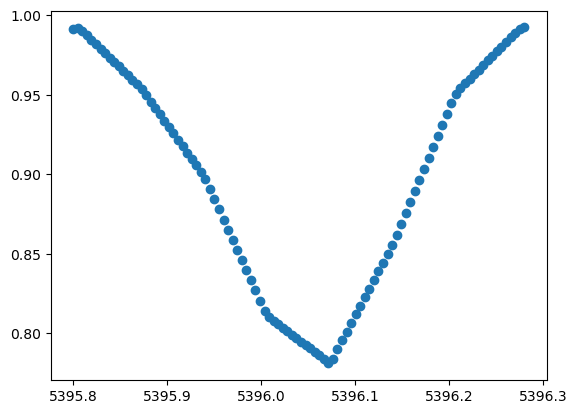

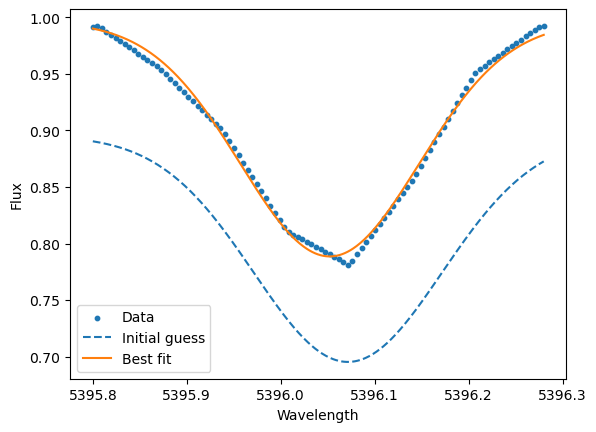

In [11]:
x, y = np.loadtxt('linija.txt', skiprows=1, unpack=True) #učitavam podatke iz fajla, preskačem prvu liniju u kojoj mi nisu brojevi, i unpack=true da mi 
#razdvoji podatke u kolone

plt.scatter(x, y) #prikazujem podatke tačkicama

#definišem gausovu funkciju
def gauss(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

#sad od oka pokušavam da pogodim kako mogu da opišem svoje podatke gausom
A_guess = -0.2          #apsorbicona linija ima negativnu amplutudu, procenjujem da je ovolika otrpilike
mu_guess = x[np.argmin(y)]   # centar u blizini minimuma
sigma_guess = 0.1       # širina krive
C_guess = np.mean(y)    #kontinuum (sve ove vrijednosti ''od oka'')

p0 = [A_guess, mu_guess, sigma_guess, C_guess] #ovo su moji početni parametri fita - očekujem da budu bliski ovim vrijednostima

#sad zapravo fitujem, tj. pokušavam da opišem svoje posmatrane podatke teorijskom funkcijom 
popt, pcov = curve_fit(gauss, x, y, p0=p0) #prosleđujem kojom funkcijom koje podatke želim da fitujem, i dajem pretpostavku za parametre (ovo nije obavezno, ali
#u nekim slučajevima fit neće da konvergira ako nema početnih pretpostavki)
#nazivam ih popt i pcov kao - parameters_optimal i parameters_covariance (iako možete da ih zovete kako hoćete, ovo je najčešće)
A_fit, mu_fit, sigma_fit, C_fit = popt #razdavajam parametre fita, dati su mi istim redom kako sam navela promenljive kada sam definisala funkciju kao
#gaus(x, A, mu, sigma, C)

#štampam rezultate
print("Parametri fita")
print(f"A = {A_fit}")
print(f"mu = {mu_fit}")
print(f"sigma = {sigma_fit}")
print(f"C = {C_fit}")


#definišem novi niz x ose od 500 tačaka
x_fit = np.linspace(min(x), max(x), 500)

plt.figure()

plt.scatter(x, y, label="Data", s=10) #plotujem podatke
plt.plot(x_fit, gauss(x_fit, *p0), '--', label="Initial guess") #plotujem ono što sam ''od oka'' pretpostavila 
plt.plot(x_fit, gauss(x_fit, *popt), label="Best fit") #prikazujem fit

plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()

plt.show()